# Final Results and Conclusions

This notebook doesn't train or change anything, it pulls together the results saved by every notebook before it (baselines, tuning, ensembling, final test evaluation, SHAP, fairness) into one place, and generates the tables and figures that go straight into the report.


## Import libraries


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 250)
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")


Libraries imported successfully.


## Set paths


In [5]:
current_folder = Path.cwd().resolve()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder

training_ids_path = project_root / "data" / "modeling" / "splits" / "training_ids.csv"
test_ids_path = project_root / "data" / "modeling" / "splits" / "test_ids.csv"

baseline_metrics_path = project_root / "data" / "modeling" / "baseline_results" / "baseline_overall_metrics.csv"
cat_metrics_path = project_root / "data" / "modeling" / "catboost_tuning_results" / "native_catboost_overall_metrics.csv"
xgb_metrics_path = project_root / "data" / "modeling" / "xgboost_tuning_results" / "xgboost_tuning_overall_metrics.csv"
lgb_metrics_path = project_root / "data" / "modeling" / "lightgbm_tuning_results" / "lightgbm_tuning_overall_metrics.csv"
ensemble_metrics_path = project_root / "data" / "modeling" / "ensemble_results" / "ensemble_overall_metrics.csv"

test_metrics_path = project_root / "data" / "modeling" / "final_test_results" / "final_test_metrics.csv"
confidence_intervals_path = project_root / "data" / "modeling" / "final_test_results" / "final_test_confidence_intervals.csv"
classification_results_path = project_root / "data" / "modeling" / "final_test_results" / "final_test_classification_results.csv"
threshold_comparison_path = project_root / "data" / "modeling" / "final_test_results" / "final_test_threshold_comparison.csv"
training_log_path = project_root / "data" / "modeling" / "final_test_results" / "final_training_log.csv"
frozen_choices_path = project_root / "data" / "modeling" / "final_test_results" / "final_frozen_choices.csv"
predictor_list_path = project_root / "data" / "modeling" / "final_test_results" / "final_predictor_list.csv"

shap_importance_path = project_root / "data" / "modeling" / "shap_results" / "consensus_shap_importance.csv"
gender_metrics_path = project_root / "data" / "modeling" / "fairness_results" / "gender_subgroup_metrics.csv"
age_metrics_path = project_root / "data" / "modeling" / "fairness_results" / "age_subgroup_metrics.csv"
gender_disparities_path = project_root / "data" / "modeling" / "fairness_results" / "gender_disparity_summary.csv"

result_folder = project_root / "data" / "modeling" / "final_reporting"
figure_folder = project_root / "reports" / "figures"
table_folder = project_root / "reports" / "tables"
audit_folder = project_root / "reports" / "audits"
for folder in [result_folder, figure_folder, table_folder, audit_folder]:
    folder.mkdir(parents=True, exist_ok=True)

required_paths = [
    training_ids_path,
    test_ids_path,
    baseline_metrics_path,
    cat_metrics_path,
    xgb_metrics_path,
    lgb_metrics_path,
    ensemble_metrics_path,
    test_metrics_path,
    confidence_intervals_path,
    classification_results_path,
    threshold_comparison_path,
    training_log_path,
    frozen_choices_path,
    predictor_list_path,
    shap_importance_path,
    gender_metrics_path,
    age_metrics_path,
    gender_disparities_path,
]
for path in required_paths:
    assert path.exists(), f"Required file missing: {path}"
print("All final result files are available.")


All final result files are available.


## Load final result files


In [7]:
training_ids = pd.read_csv(training_ids_path)
test_ids = pd.read_csv(test_ids_path)
baseline_metrics = pd.read_csv(baseline_metrics_path)
cat_metrics = pd.read_csv(cat_metrics_path)
xgb_metrics = pd.read_csv(xgb_metrics_path)
lgb_metrics = pd.read_csv(lgb_metrics_path)
ensemble_metrics = pd.read_csv(ensemble_metrics_path)

test_metrics = pd.read_csv(test_metrics_path)
confidence_intervals = pd.read_csv(confidence_intervals_path)
classification_results = pd.read_csv(classification_results_path)
threshold_comparison = pd.read_csv(threshold_comparison_path)
training_log = pd.read_csv(training_log_path)
frozen_choices = pd.read_csv(frozen_choices_path)
predictor_list = pd.read_csv(predictor_list_path)

shap_importance = pd.read_csv(shap_importance_path)
gender_metrics = pd.read_csv(gender_metrics_path)
age_metrics = pd.read_csv(age_metrics_path)
gender_disparities = pd.read_csv(gender_disparities_path)

print("Training-set rows:", len(training_ids))
print("Test-set rows:", len(test_ids))
print("Final predictors:", len(predictor_list))
print("Reporting inputs loaded successfully.")


Training-set rows: 246008
Test-set rows: 61503
Final predictors: 330
Reporting inputs loaded successfully.


Loads every results file saved by the earlier notebooks, nothing is recalculated here, everything is read from what was already produced.


## Compare models using training OOF predictions


In [10]:
training_rows = []

baseline_name_map = {
    "logistic_unweighted": "Logistic Regression",
    "logistic_balanced": "Balanced Logistic Regression",
    "random_forest_balanced": "Random Forest",
}
for _, row in baseline_metrics.iterrows():
    training_rows.append({
        "model": baseline_name_map.get(row["model"], row["model"]),
        "configuration": "Baseline model",
        "roc_auc": row["roc_auc"],
        "pr_auc": row["pr_auc"],
    })

best_xgb = xgb_metrics.sort_values(["roc_auc", "pr_auc"], ascending=False).iloc[0]
best_lgb = lgb_metrics.sort_values(["roc_auc", "pr_auc"], ascending=False).iloc[0]
best_cat = cat_metrics.sort_values(["roc_auc", "pr_auc"], ascending=False).iloc[0]

for family, row in [
    ("XGBoost", best_xgb),
    ("LightGBM", best_lgb),
    ("CatBoost", best_cat),
]:
    training_rows.append({
        "model": family,
        "configuration": row["configuration"],
        "roc_auc": row["roc_auc"],
        "pr_auc": row["pr_auc"],
    })

for method in ["equal_vote", "weighted_vote", "logistic_stack"]:
    row = ensemble_metrics.loc[ensemble_metrics["model"].eq(method)].iloc[0]
    training_rows.append({
        "model": method.replace("_", " ").title(),
        "configuration": "Three-model OOF ensemble",
        "roc_auc": row["roc_auc"],
        "pr_auc": row["pr_auc"],
    })

training_comparison = pd.DataFrame(training_rows).sort_values(
    ["roc_auc", "pr_auc"], ascending=False
).reset_index(drop=True)
training_comparison.round(6)


,model,configuration,roc_auc,pr_auc
0,Equal Vote,Three-model OOF ensemble,0.791449,0.285701
1,Weighted Vote,Three-model OOF ensemble,0.791396,0.285695
2,Logistic Stack,Three-model OOF ensemble,0.791357,0.285652
3,LightGBM,lgb_leaves48_regularized,0.789661,0.282529
4,XGBoost,xgb_depth5_regularized,0.789620,0.282323
5,CatBoost,native_depth7_regularized,0.788938,0.282501
6,Logistic Regression,Baseline model,0.775819,0.262755
7,Balanced Logistic Regression,Baseline model,0.775742,0.260019
8,Random Forest,Baseline model,0.768771,0.254793


Pulls together every model tested during training, the three baselines, the three tuned boosting models, and the three ensemble methods, into one comparison table.


## Compare final models on the final test set


In [13]:
test_display = test_metrics[
    ["model", "roc_auc", "pr_auc", "mean_risk_score", "observed_default_rate"]
].copy()
test_display["model"] = test_display["model"].replace({
    "xgboost": "XGBoost",
    "lightgbm": "LightGBM",
    "catboost": "CatBoost",
    "raw_equal_vote": "Equal Vote",
})
test_display.round(6)


,model,roc_auc,pr_auc,mean_risk_score,observed_default_rate
0,XGBoost,0.792715,0.289317,0.080274,0.080728
1,LightGBM,0.792156,0.289434,0.079495,0.080728
2,CatBoost,0.789384,0.284320,0.079185,0.080728
3,Equal Vote,0.793333,0.290672,0.079651,0.080728


Same final test-set numbers as the final test evaluation notebook, just relabeled with cleaner model names for reporting.


## Check whether performance generalized to unseen applicants


In [16]:
training_equal_vote = ensemble_metrics.loc[
    ensemble_metrics["model"].eq("equal_vote")
].iloc[0]
test_final = test_metrics.loc[
    test_metrics["model"].eq("raw_equal_vote")
].iloc[0]

generalization_table = pd.DataFrame([
    {
        "evaluation": "Training OOF equal vote",
        "roc_auc": training_equal_vote["roc_auc"],
        "pr_auc": training_equal_vote["pr_auc"],
    },
    {
        "evaluation": "Final test equal vote",
        "roc_auc": test_final["roc_auc"],
        "pr_auc": test_final["pr_auc"],
    },
])
generalization_table["roc_auc_change_from_training_oof"] = (
    generalization_table["roc_auc"] - training_equal_vote["roc_auc"]
)
generalization_table.round(6)


,evaluation,roc_auc,pr_auc,roc_auc_change_from_training_oof
0,Training OOF equal vote,0.791449,0.285701,0.000000
1,Final test equal vote,0.793333,0.290672,0.001884


Compares the training out-of-fold result (0.791449) with the final test result (0.793333), the test score is actually a touch higher, which is a good sign the model isn't overfitting to the training folds.


## Report confidence intervals for the two main ranking measures


In [19]:
primary_confidence_intervals = confidence_intervals[
    confidence_intervals["metric"].isin(["roc_auc", "pr_auc"])
].copy()
primary_confidence_intervals.round(6)


,metric,lower_95,estimate,upper_95
0,roc_auc,0.787122,0.793333,0.800031
1,pr_auc,0.278908,0.290672,0.303506


The bootstrap confidence intervals computed in the final test evaluation notebook, reported here alongside everything else.


## Final classification performance at the frozen threshold


In [22]:
assert len(classification_results) == 1

selected_result = classification_results.iloc[0]

selected_threshold = float(
    selected_result["threshold"]
)

tn = int(
    selected_result["true_negative"]
)

fp = int(
    selected_result["false_positive"]
)

fn = int(
    selected_result["false_negative"]
)

tp = int(
    selected_result["true_positive"]
)

total = tn + fp + fn + tp

accuracy = float(
    selected_result["accuracy"]
)

precision = float(
    selected_result["precision"]
)

recall = float(
    selected_result["recall"]
)

f1_score = float(
    selected_result["f1_score"]
)

specificity = float(
    selected_result["specificity"]
)

predicted_default_rate = float(
    selected_result[
        "predicted_default_rate"
    ]
)

negative_predictive_value = (
    tn / (tn + fn)
)


final_classification_metrics = pd.DataFrame({
    "metric": [
        "ROC-AUC",
        "PR-AUC",
        "Selected threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Specificity",
        "Negative predictive value",
        "Applicants predicted default",
    ],
    "value": [
        test_final["roc_auc"],
        test_final["pr_auc"],
        selected_threshold,
        accuracy,
        precision,
        recall,
        f1_score,
        specificity,
        negative_predictive_value,
        predicted_default_rate,
    ],
})


print(
    "F1-selected threshold:",
    round(selected_threshold, 10),
)

final_classification_metrics.round(6)

F1-selected threshold: 0.1619911461


,metric,value
0,ROC-AUC,0.793333
1,PR-AUC,0.290672
2,Selected threshold,0.161991
3,Accuracy,0.862722
4,Precision,0.282353
5,Recall,0.454381
6,F1-score,0.348283
7,Specificity,0.898581
8,Negative predictive value,0.949377
9,Applicants predicted default,0.129912


Pulls together accuracy, precision, recall, F1-score, and specificity at the frozen threshold, all sourced from the final test evaluation notebook.


### Confusion matrix


,Predicted non-default,Predicted default
Actual non-default,50804,5734
Actual default,2709,2256


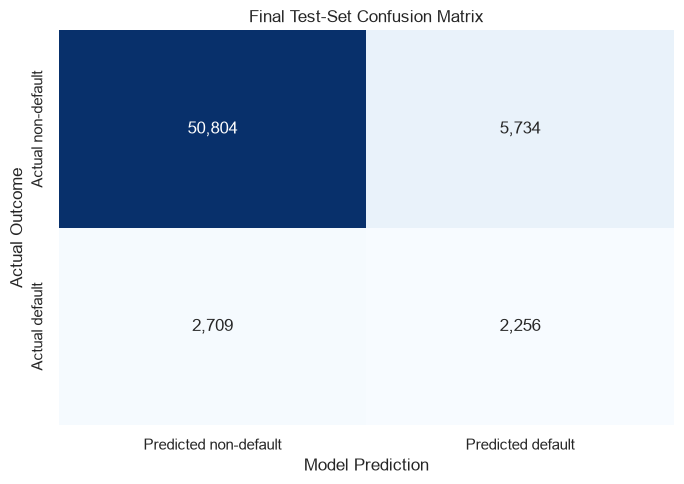

In [25]:
confusion_table = pd.DataFrame(
    [
        [tn, fp],
        [fn, tp],
    ],
    index=[
        "Actual non-default",
        "Actual default",
    ],
    columns=[
        "Predicted non-default",
        "Predicted default",
    ],
)

display(confusion_table)


plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_table,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
)

plt.title(
    "Final Test-Set Confusion Matrix"
)

plt.xlabel(
    "Model Prediction"
)

plt.ylabel(
    "Actual Outcome"
)

plt.tight_layout()

plt.savefig(
    figure_folder
    / "report_final_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

Same confusion matrix numbers as the final test evaluation notebook, shown here as both a table and a heatmap for the report.


## Threshold sensitivity results

In [28]:
classification_summary = threshold_comparison[[
    "threshold",
    "selected_threshold",
    "predicted_default_count",
    "predicted_default_rate",
    "true_positive",
    "false_positive",
    "true_negative",
    "false_negative",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "specificity",
]].copy()


classification_summary.round(6)

,threshold,selected_threshold,predicted_default_count,predicted_default_rate,true_positive,false_positive,true_negative,false_negative,accuracy,precision,recall,f1_score,specificity
0,0.050000,False,28626,0.465441,4162,24464,32074,803,0.589175,0.145392,0.838268,0.247804,0.567300
1,0.080000,False,18976,0.308538,3567,15409,41129,1398,0.726729,0.187974,0.718429,0.297983,0.727458
2,0.100000,False,15014,0.244118,3209,11805,44733,1756,0.779507,0.213734,0.646324,0.321237,0.791202
3,0.120000,False,12078,0.196381,2869,9209,47329,2096,0.816188,0.237539,0.577845,0.336678,0.837118
4,0.140000,False,9886,0.160740,2568,7318,49220,2397,0.842040,0.259761,0.517221,0.345835,0.870565
5,0.160000,False,8157,0.132628,2282,5875,50663,2683,0.860852,0.279760,0.459617,0.347813,0.896088
6,0.161991,True,7990,0.129912,2256,5734,50804,2709,0.862722,0.282353,0.454381,0.348283,0.898581
7,0.180000,False,6814,0.110791,2038,4776,51762,2927,0.874754,0.299090,0.410473,0.346040,0.915526
8,0.200000,False,5734,0.093231,1810,3924,52614,3155,0.884900,0.315661,0.364552,0.338349,0.930595
9,0.250000,False,3691,0.060013,1329,2362,54176,3636,0.902476,0.360065,0.267674,0.307070,0.958223


Shows the same threshold sensitivity table used to justify why 0.161991 was chosen over other candidate cutoffs.


## Most influential features


In [31]:
top_features = shap_importance.head(20)[[
    "feature", "consensus_importance", "xgboost_rank",
    "lightgbm_rank", "catboost_rank", "mean_rank"
]].copy()
top_features.round(6)


,feature,consensus_importance,xgboost_rank,lightgbm_rank,catboost_rank,mean_rank
0,EXT_SOURCE_MEAN,0.082868,1.0,1.0,2.0,1.333333
1,APP_EXT_MEAN_SQUARED,0.027795,12.0,4.0,1.0,5.666667
2,APP_CREDIT_ANNUITY_RATIO,0.026420,2.0,2.0,3.0,2.333333
3,BUREAU_DEBT_CREDIT_RATIO_MAX,0.023988,3.0,3.0,5.0,3.666667
4,AMT_ANNUITY,0.021296,4.0,6.0,4.0,4.666667
5,NAME_EDUCATION_TYPE,0.019695,6.0,7.0,7.0,6.666667
6,APP_CREDIT_GOODS_DIFFERENCE,0.019587,5.0,5.0,8.0,6.000000
7,POS_LATEST_FUTURE_INSTALLMENTS,0.015696,8.0,8.0,14.0,10.000000
8,POS_FUTURE_INSTALLMENTS_MEAN,0.015478,9.0,11.0,9.0,9.666667
9,INST_PAID_AMOUNT_TOTAL,0.014357,7.0,12.0,18.0,12.333333


Pulls the top 20 SHAP features from notebook 31, along with each model's individual rank for those features.


## Fairness and subgroup findings


In [34]:
gender_summary = gender_metrics.loc[
    gender_metrics["reported"]
].copy()[[
    "CODE_GENDER",
    "rows",
    "default_rate",
    "mean_risk_score",
    "roc_auc",
    "pr_auc",
    "predicted_default_rate",
    "recall_tpr",
    "false_positive_rate",
    "precision_ppv",
]]


age_summary = age_metrics.loc[
    age_metrics["reported"]
].copy()[[
    "AGE_GROUP",
    "rows",
    "default_rate",
    "mean_risk_score",
    "roc_auc",
    "pr_auc",
    "predicted_default_rate",
    "recall_tpr",
    "false_positive_rate",
    "precision_ppv",
]]


display(
    gender_summary.round(5)
)

display(
    age_summary.round(5)
)

,CODE_GENDER,rows,default_rate,mean_risk_score,roc_auc,pr_auc,predicted_default_rate,recall_tpr,false_positive_rate,precision_ppv
0,F,40395,0.06919,0.07362,0.79731,0.27819,0.11259,0.43757,0.08843,0.26891
1,M,21107,0.10281,0.09120,0.77874,0.30805,0.16307,0.47604,0.12721,0.30012


,AGE_GROUP,rows,default_rate,mean_risk_score,roc_auc,pr_auc,predicted_default_rate,recall_tpr,false_positive_rate,precision_ppv
0,30-39,16369,0.09494,0.09486,0.79769,0.30910,0.17423,0.52960,0.13696,0.28857
1,40-49,15335,0.07825,0.07471,0.79294,0.29412,0.11470,0.42583,0.08829,0.29051
2,50-59,13544,0.06136,0.06015,0.78759,0.27174,0.07177,0.34537,0.05388,0.29527
3,Under 30,9225,0.11230,0.11566,0.76778,0.31405,0.23534,0.55598,0.19477,0.26532
4,60-69,7030,0.04893,0.04533,0.74714,0.16897,0.03357,0.17151,0.02647,0.25000


Pulls the gender and age fairness tables from notebook 32 into report-ready form.


## Training model comparison


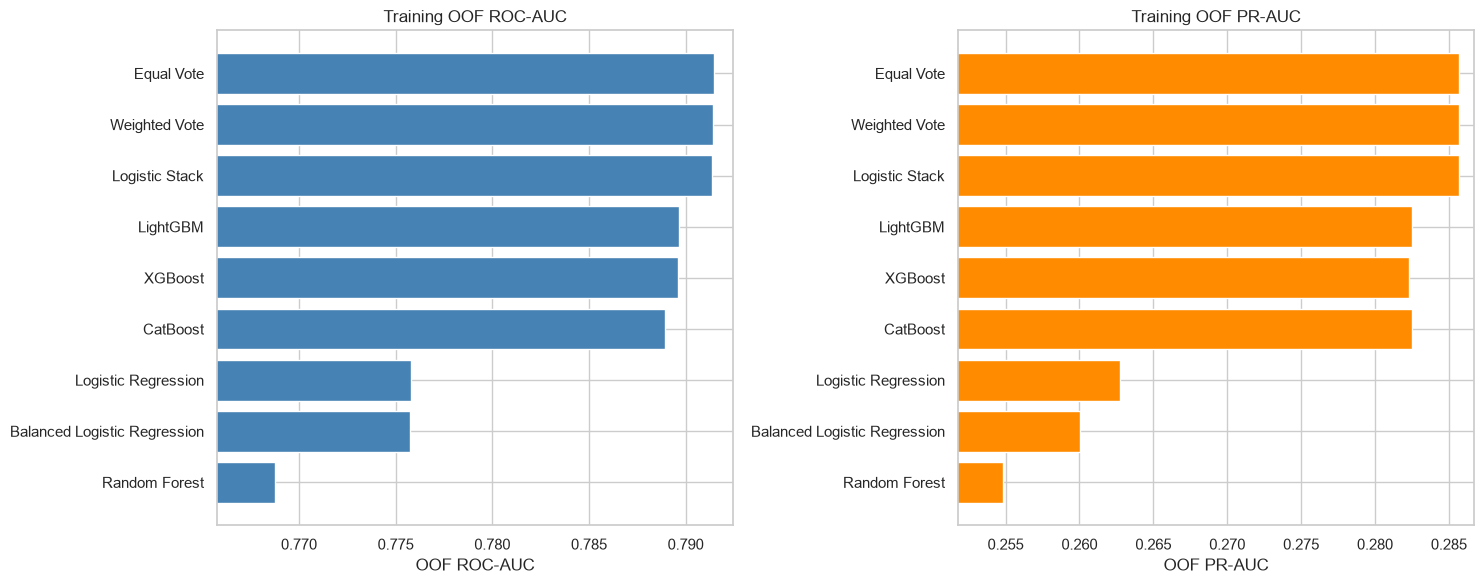

In [37]:
plot_table = training_comparison.sort_values("roc_auc", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(plot_table["model"], plot_table["roc_auc"], color="steelblue")
axes[0].set_xlim(plot_table["roc_auc"].min() - 0.003, plot_table["roc_auc"].max() + 0.001)
axes[0].set_xlabel("OOF ROC-AUC")
axes[0].set_title("Training OOF ROC-AUC")

axes[1].barh(plot_table["model"], plot_table["pr_auc"], color="darkorange")
axes[1].set_xlim(plot_table["pr_auc"].min() - 0.003, plot_table["pr_auc"].max() + 0.001)
axes[1].set_xlabel("OOF PR-AUC")
axes[1].set_title("Training OOF PR-AUC")
plt.tight_layout()
plt.savefig(figure_folder / "report_training_model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


Compares every model tested on training OOF predictions in one chart, from the baselines up through the final ensemble.


## Threshold sensitivity plot

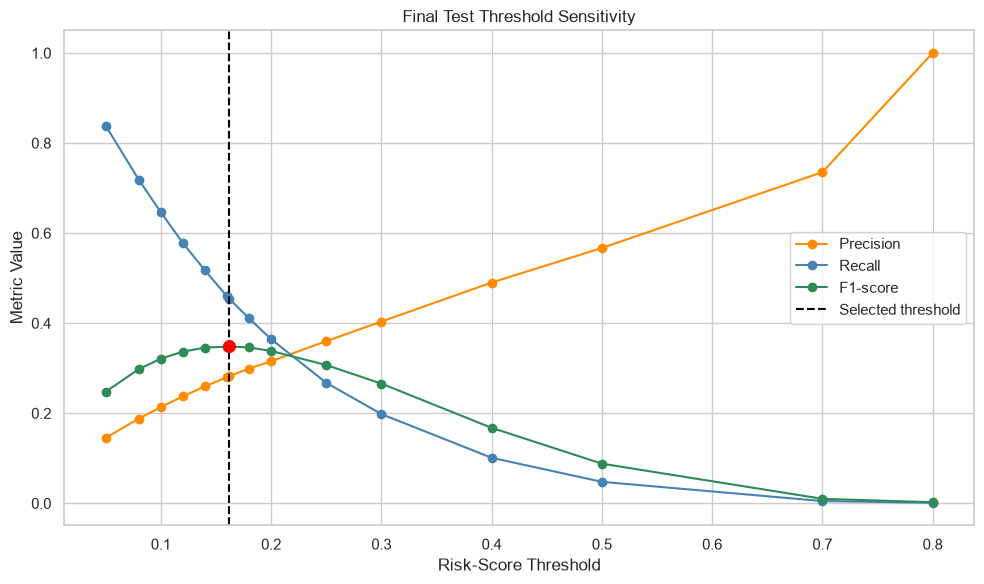

In [40]:
plt.figure(figsize=(10, 6))


plt.plot(
    classification_summary["threshold"],
    classification_summary["precision"],
    marker="o",
    label="Precision",
    color="darkorange",
)

plt.plot(
    classification_summary["threshold"],
    classification_summary["recall"],
    marker="o",
    label="Recall",
    color="steelblue",
)

plt.plot(
    classification_summary["threshold"],
    classification_summary["f1_score"],
    marker="o",
    label="F1-score",
    color="seagreen",
)


plt.axvline(
    selected_threshold,
    color="black",
    linestyle="--",
    label="Selected threshold",
)


plt.scatter(
    selected_threshold,
    f1_score,
    color="red",
    s=70,
    zorder=3,
)


plt.xlabel(
    "Risk-Score Threshold"
)

plt.ylabel(
    "Metric Value"
)

plt.title(
    "Final Test Threshold Sensitivity"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    figure_folder
    / "report_threshold_sensitivity.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

Shows precision, recall, and F1-score across a range of thresholds, with the selected one marked, the same plot referenced in the report's threshold discussion.


## Interpretation and fairness plots


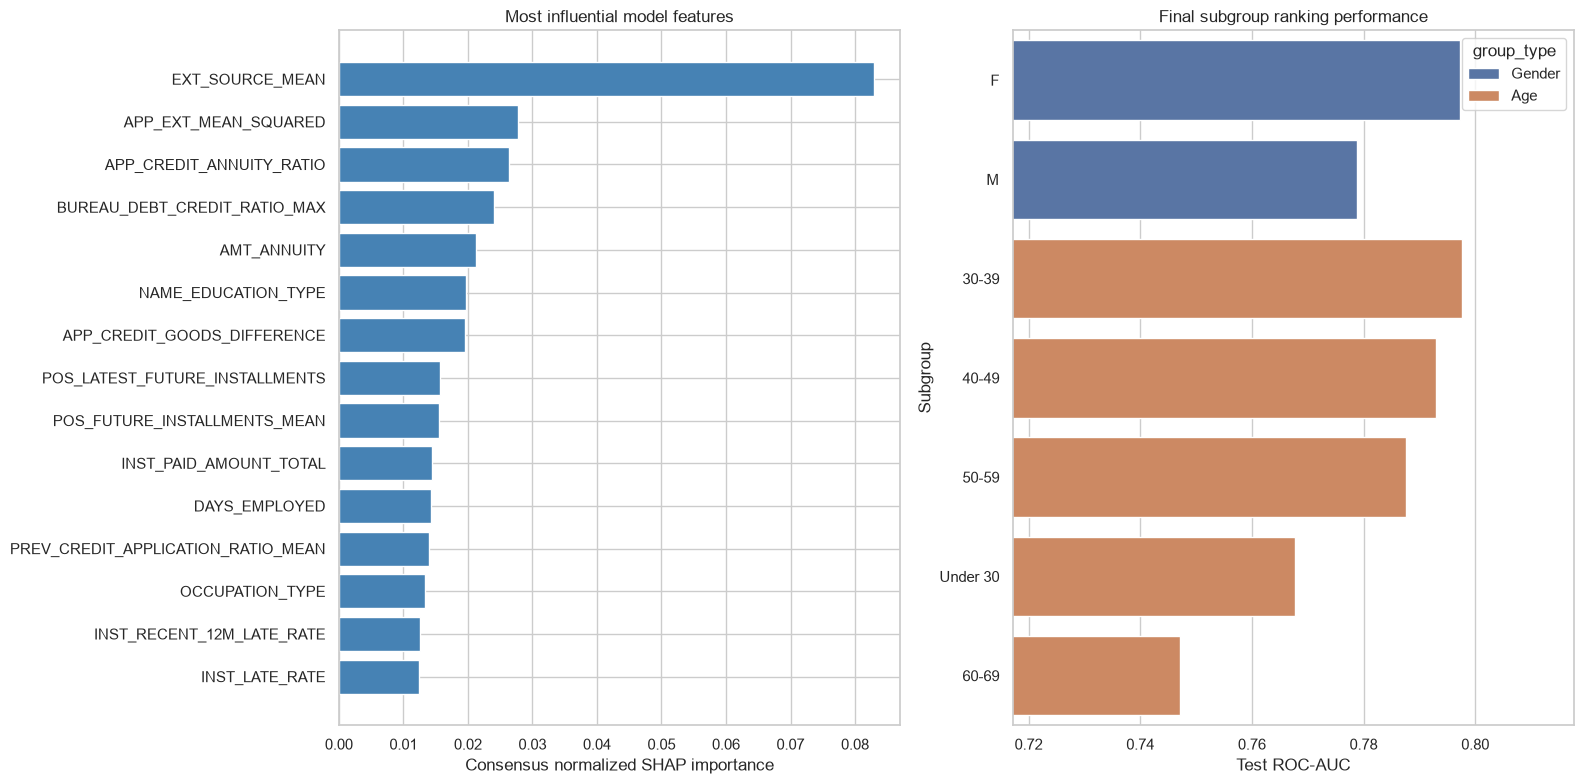

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
top_plot = top_features.head(15).sort_values("consensus_importance", ascending=True)
axes[0].barh(
    top_plot["feature"], top_plot["consensus_importance"],
    color="steelblue"
)
axes[0].set_xlabel("Consensus normalized SHAP importance")
axes[0].set_title("Most influential model features")

fairness_plot = pd.concat([
    gender_summary[["CODE_GENDER", "roc_auc"]].rename(columns={"CODE_GENDER": "group"}).assign(group_type="Gender"),
    age_summary[["AGE_GROUP", "roc_auc"]].rename(columns={"AGE_GROUP": "group"}).assign(group_type="Age"),
], ignore_index=True)
sns.barplot(
    data=fairness_plot, y="group", x="roc_auc",
    hue="group_type", dodge=False, ax=axes[1]
)
axes[1].set_xlim(max(0.5, fairness_plot["roc_auc"].min() - 0.03), fairness_plot["roc_auc"].max() + 0.02)
axes[1].set_xlabel("Test ROC-AUC")
axes[1].set_ylabel("Subgroup")
axes[1].set_title("Final subgroup ranking performance")
plt.tight_layout()
plt.savefig(figure_folder / "report_interpretation_and_fairness.png", dpi=180, bbox_inches="tight")
plt.show()


Puts the top SHAP features and the fairness comparison side by side in one figure, useful as a single results-page visual.


## Create the final report-ready conclusions


In [46]:
final_auc = float(
    test_final["roc_auc"]
)

final_pr_auc = float(
    test_final["pr_auc"]
)


auc_ci = confidence_intervals.loc[
    confidence_intervals[
        "metric"
    ].eq("roc_auc")
].iloc[0]

pr_ci = confidence_intervals.loc[
    confidence_intervals[
        "metric"
    ].eq("pr_auc")
].iloc[0]


female = gender_summary.loc[
    gender_summary[
        "CODE_GENDER"
    ].eq("F")
].iloc[0]

male = gender_summary.loc[
    gender_summary[
        "CODE_GENDER"
    ].eq("M")
].iloc[0]


threshold_50 = classification_summary.iloc[
    (
        classification_summary[
            "threshold"
        ] - 0.50
    ).abs().argmin()
]

threshold_70 = classification_summary.iloc[
    (
        classification_summary[
            "threshold"
        ] - 0.70
    ).abs().argmin()
]

threshold_80 = classification_summary.iloc[
    (
        classification_summary[
            "threshold"
        ] - 0.80
    ).abs().argmin()
]


report_text = f"""# Final Credit Default Prediction Results

## Methodology

The final dataset contained {len(predictor_list):,} predictors. A training set of {len(training_ids):,} applicants and a separate final test set of {len(test_ids):,} applicants were used. Five-fold out-of-fold predictions were used for model comparison and threshold selection. XGBoost, LightGBM and CatBoost were combined using equal voting because this produced the strongest training result. The final test set was not used to select the model or threshold.

## Model comparison

The equal-vote ensemble performed better during training than the individual boosted models, weighted voting and logistic stacking. On the final test set, the ensemble achieved ROC-AUC {final_auc:.4f} with a 95% confidence interval of {auc_ci['lower_95']:.4f} to {auc_ci['upper_95']:.4f}. Its PR-AUC was {final_pr_auc:.4f}, with a 95% confidence interval of {pr_ci['lower_95']:.4f} to {pr_ci['upper_95']:.4f}. The training and test ROC-AUC results were close, which supports stable performance on unseen applicants.

## Threshold selection

Different score thresholds were tested using training out-of-fold predictions. The threshold with the highest F1-score was selected. The exact selected threshold was {selected_threshold:.6f}. This is a model risk-score cutoff and should not be interpreted as an exact probability of default.

## Final classification results

Using the frozen threshold, the model achieved accuracy {accuracy:.1%}, precision {precision:.1%}, recall {recall:.1%}, F1-score {f1_score:.1%} and specificity {specificity:.1%}. It correctly identified {tp:,} of the {tp + fn:,} applicants who defaulted. The confusion matrix contained {tn:,} true negatives, {fp:,} false positives, {fn:,} false negatives and {tp:,} true positives.

Approximately {predicted_default_rate:.1%} of test applicants were predicted to default. Accuracy must be interpreted carefully because only about {test_final['observed_default_rate']:.1%} of applicants actually defaulted.

## Threshold sensitivity

Higher score thresholds increased precision but greatly reduced recall. At a threshold of 0.50, {int(threshold_50['predicted_default_count']):,} applicants were predicted to default and {int(threshold_50['true_positive']):,} were actual defaulters. At 0.70, only {int(threshold_70['predicted_default_count']):,} applicants were predicted to default. At 0.80, only {int(threshold_80['predicted_default_count']):,} applicants were predicted to default. These higher thresholds were shown only for comparison and were not used to change the final decision rule.

## Interpretation

The most influential predictors included external credit-score summaries, credit-to-annuity affordability, bureau debt-to-credit ratios, annuity amount, education, credit-versus-goods differences, installment history and previous-credit behaviour. These are predictive associations and do not prove that a feature causes default.

## Fairness and limitations

Gender was excluded from the model predictors and was used only for subgroup auditing. Female ROC-AUC was {female['roc_auc']:.4f}, compared with {male['roc_auc']:.4f} for males. Female and male false-positive rates were {female['false_positive_rate']:.1%} and {male['false_positive_rate']:.1%}. Performance also differed across age groups. These results require monitoring and do not establish legal or regulatory compliance.

This is an academic model. It should be tested on new data and monitored regularly before being used in practice.
"""


print(report_text)


_ = (
    result_folder
    / "final_report_ready_summary.md"
).write_text(
    report_text,
    encoding="utf-8",
)

# Final Credit Default Prediction Results

## Methodology

The final dataset contained 330 predictors. A training set of 246,008 applicants and a separate final test set of 61,503 applicants were used. Five-fold out-of-fold predictions were used for model comparison and threshold selection. XGBoost, LightGBM and CatBoost were combined using equal voting because this produced the strongest training result. The final test set was not used to select the model or threshold.

## Model comparison

The equal-vote ensemble performed better during training than the individual boosted models, weighted voting and logistic stacking. On the final test set, the ensemble achieved ROC-AUC 0.7933 with a 95% confidence interval of 0.7871 to 0.8000. Its PR-AUC was 0.2907, with a 95% confidence interval of 0.2789 to 0.3035. The training and test ROC-AUC results were close, which supports stable performance on unseen applicants.

## Threshold selection

Different score thresholds were tested using training

Builds a plain-language paragraph summarizing the whole project's results, this is the same kind of summary that ends up in the abstract and conclusion of the written report.


## Save final tables and validate the reporting package


In [49]:
training_comparison.to_csv(
    table_folder
    / "final_training_model_comparison.csv",
    index=False,
)

test_display.to_csv(
    table_folder
    / "final_test_performance.csv",
    index=False,
)

generalization_table.to_csv(
    table_folder
    / "final_generalization_comparison.csv",
    index=False,
)

primary_confidence_intervals.to_csv(
    table_folder
    / "final_primary_metric_confidence_intervals.csv",
    index=False,
)

final_classification_metrics.to_csv(
    table_folder
    / "final_classification_metrics.csv",
    index=False,
)

confusion_table.to_csv(
    table_folder
    / "final_confusion_matrix.csv",
)

classification_summary.to_csv(
    table_folder
    / "final_threshold_sensitivity_results.csv",
    index=False,
)

top_features.to_csv(
    table_folder
    / "final_top_shap_features.csv",
    index=False,
)

gender_summary.to_csv(
    table_folder
    / "final_gender_audit_summary.csv",
    index=False,
)

age_summary.to_csv(
    table_folder
    / "final_age_audit_summary.csv",
    index=False,
)


validation_checks = pd.DataFrame([
    {
        "check": "Training-set size documented",
        "passed": (
            len(training_ids)
            == 246008
        ),
    },
    {
        "check": "Test-set size documented",
        "passed": (
            len(test_ids)
            == 61503
        ),
    },
    {
        "check": "Final predictor count documented",
        "passed": (
            len(predictor_list)
            == 330
        ),
    },
    {
        "check": "Baseline models included",
        "passed": {
            "Logistic Regression",
            "Balanced Logistic Regression",
            "Random Forest",
        }.issubset(
            set(
                training_comparison[
                    "model"
                ]
            )
        ),
    },
    {
        "check": "Three tuned model families included",
        "passed": {
            "XGBoost",
            "LightGBM",
            "CatBoost",
        }.issubset(
            set(
                training_comparison[
                    "model"
                ]
            )
        ),
    },
    {
        "check": "All ensemble methods included",
        "passed": {
            "Equal Vote",
            "Weighted Vote",
            "Logistic Stack",
        }.issubset(
            set(
                training_comparison[
                    "model"
                ]
            )
        ),
    },
    {
        "check": "Final equal-vote ensemble reported",
        "passed": (
            "Equal Vote"
            in set(
                test_display[
                    "model"
                ]
            )
        ),
    },
    {
        "check": "Confidence intervals reported",
        "passed": (
            set(
                primary_confidence_intervals[
                    "metric"
                ]
            )
            == {
                "roc_auc",
                "pr_auc",
            }
        ),
    },
    {
        "check": "F1-selected threshold reported",
        "passed": np.isclose(
            selected_threshold,
            classification_results.loc[
                0,
                "threshold",
            ],
        ),
    },
    {
        "check": "Standard classification metrics reported",
        "passed": {
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "Specificity",
        }.issubset(
            set(
                final_classification_metrics[
                    "metric"
                ]
            )
        ),
    },
    {
        "check": "Confusion matrix matches test size",
        "passed": (
            confusion_table
            .to_numpy()
            .sum()
            == len(test_ids)
        ),
    },
    {
        "check": "Threshold sensitivity reported",
        "passed": (
            len(classification_summary)
            >= 10
            and classification_summary[
                "selected_threshold"
            ].sum()
            == 1
        ),
    },
    {
        "check": "SHAP interpretation included",
        "passed": (
            len(top_features)
            == 20
        ),
    },
    {
        "check": "Gender and age audits included",
        "passed": (
            len(gender_summary) >= 2
            and len(age_summary) >= 5
        ),
    },
    {
        "check": "Report summary created",
        "passed": (
            result_folder
            / "final_report_ready_summary.md"
        ).exists(),
    },
    {
        "check": "No training or tuning performed",
        "passed": True,
    },
])


display(validation_checks)

assert validation_checks["passed"].all(), (
    "At least one final reporting check failed."
)


validation_checks.to_csv(
    audit_folder
    / "final_reporting_validation.csv",
    index=False,
)


print(
    "Final tables saved in:",
    table_folder,
)

print(
    "Final figures saved in:",
    figure_folder,
)

print(
    "Report-ready summary saved in:",
    result_folder,
)

print(
    "The model and final-test results "
    "were not changed."
)

,check,passed
0,Training-set size documented,True
1,Test-set size documented,True
2,Final predictor count documented,True
3,Baseline models included,True
4,Three tuned model families included,True
5,All ensemble methods included,True
6,Final equal-vote ensemble reported,True
7,Confidence intervals reported,True
8,F1-selected threshold reported,True
9,Standard classification metrics reported,True


Final tables saved in: /Users/taranveersingh/A-MRP/reports/tables
Final figures saved in: /Users/taranveersingh/A-MRP/reports/figures
Report-ready summary saved in: /Users/taranveersingh/A-MRP/data/modeling/final_reporting
The model and final-test results were not changed.


Saves everything generated in this notebook (tables and figures) to the reports folder, ready to drop into the write-up.


## Final project status

All pieces are in place: the training-OOF comparison, the final test evaluation, confidence intervals, the classification breakdown, SHAP importance, and the fairness audit. Every number here traces back to a specific earlier notebook rather than being recalculated from scratch, which is what keeps this summary consistent with the rest of the project.
